In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv("user_behavior_dataset.csv")

# Quick look
print(df.shape)       
df.head()             # First 5 rows

(700, 11)


,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [4]:
# Select only the behavior columns
features = ['App Usage Time (min/day)', 'Screen On Time (hours/day)',
            'Battery Drain (mAh/day)', 'Number of Apps Installed',
            'Data Usage (MB/day)', 'Age']

X = df[features]

# Check for missing values (important!)
print(X.isnull().sum())  # Should all be 0 for this dataset

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print( X_scaled.shape)

App Usage Time (min/day)      0
Screen On Time (hours/day)    0
Battery Drain (mAh/day)       0
Number of Apps Installed      0
Data Usage (MB/day)           0
Age                           0
dtype: int64
(700, 6)


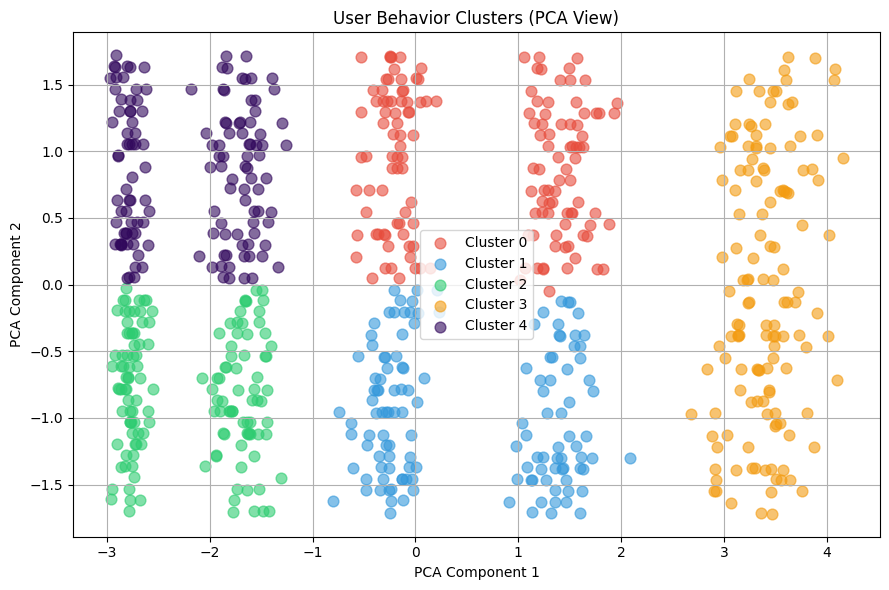

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Step 1: Apply K-Means with K=4
km = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X_scaled)

# Step 2: Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 3: Plot the clusters
plt.figure(figsize=(9, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12' , "#31085c"]

for cluster in range(5):
    mask = df['Cluster'] == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {cluster}',
                color=colors[cluster], alpha=0.6, s=60)

plt.title('User Behavior Clusters (PCA View)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# See the average behavior of each cluster
cluster_summary = df.groupby('Cluster')[features].mean().round(2)
print(cluster_summary)

         App Usage Time (min/day)  Screen On Time (hours/day)  \
Cluster                                                         
0                          320.91                        5.99   
1                          307.28                        5.84   
2                           96.56                        2.18   
3                          541.42                       10.11   
4                           98.42                        2.41   

         Battery Drain (mAh/day)  Number of Apps Installed  \
Cluster                                                      
0                        1832.14                     60.14   
1                        1777.64                     59.47   
2                         686.69                     22.42   
3                        2701.01                     89.25   
4                         666.88                     23.49   

         Data Usage (MB/day)    Age  
Cluster                              
0                    1038.93  49.

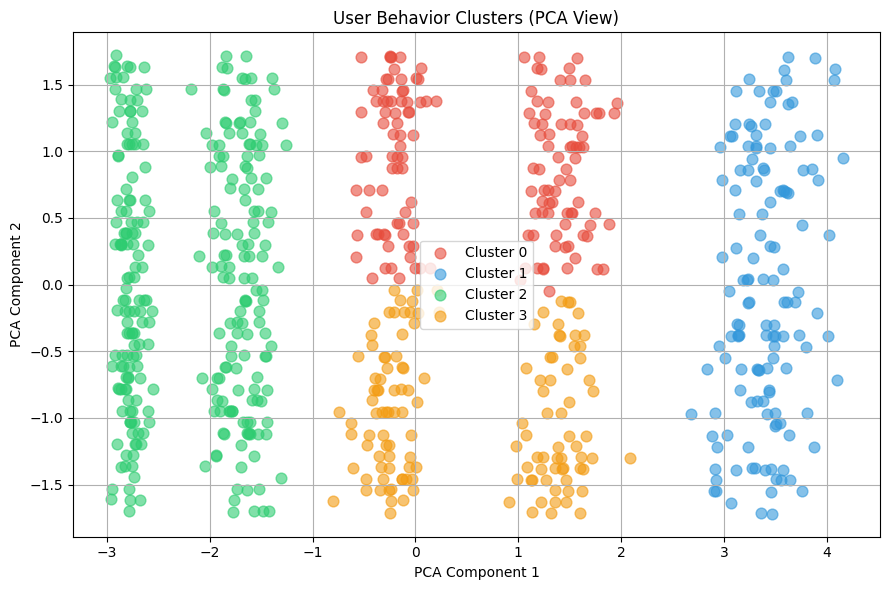

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Step 1: Apply K-Means with K=4
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X_scaled)

# Step 2: Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 3: Plot the clusters
plt.figure(figsize=(9, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12' ]

for cluster in range(4):
    mask = df['Cluster'] == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {cluster}',
                color=colors[cluster], alpha=0.6, s=60)

plt.title('User Behavior Clusters (PCA View)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
# See the average behavior of each cluster
cluster_summary = df.groupby('Cluster')[features].mean().round(2)
print(cluster_summary)

         App Usage Time (min/day)  Screen On Time (hours/day)  \
Cluster                                                         
0                          320.91                        5.99   
1                          541.42                       10.11   
2                           97.47                        2.29   
3                          307.28                        5.84   

         Battery Drain (mAh/day)  Number of Apps Installed  \
Cluster                                                      
0                        1832.14                     60.14   
1                        2701.01                     89.25   
2                         677.00                     22.94   
3                        1777.64                     59.47   

         Data Usage (MB/day)    Age  
Cluster                              
0                    1038.93  49.31  
1                    1974.77  38.18  
2                     331.29  38.44  
3                    1007.96  26.93  


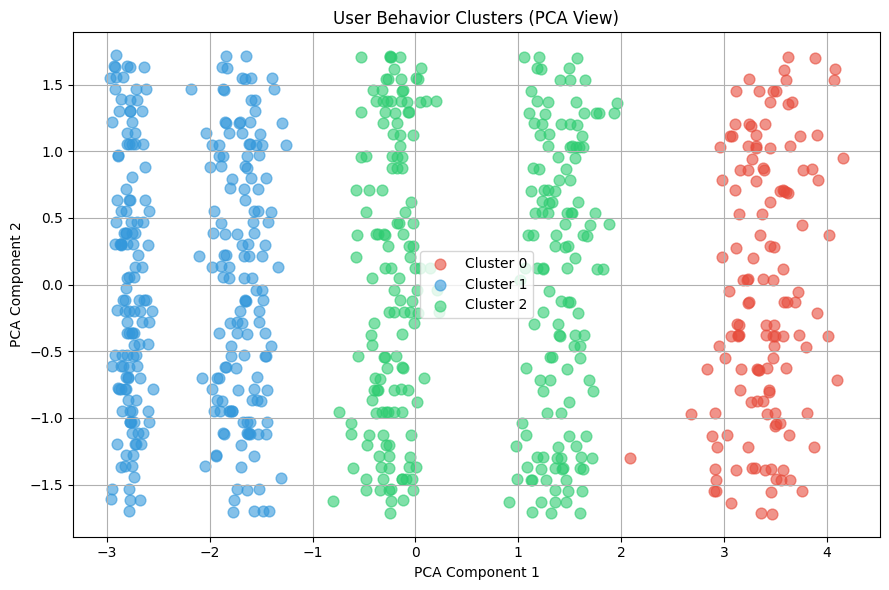

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Step 1: Apply K-Means with K=3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X_scaled)

# Step 2: Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 3: Plot the clusters
plt.figure(figsize=(9, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71' ]

for cluster in range(3):
    mask = df['Cluster'] == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {cluster}',
                color=colors[cluster], alpha=0.6, s=60)

plt.title('User Behavior Clusters (PCA View)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# See the average behavior of each cluster
cluster_summary = df.groupby('Cluster')[features].mean().round(2)
print(cluster_summary)

         App Usage Time (min/day)  Screen On Time (hours/day)  \
Cluster                                                         
0                          540.69                       10.10   
1                           97.47                        2.29   
2                          313.99                        5.91   

         Battery Drain (mAh/day)  Number of Apps Installed  \
Cluster                                                      
0                        2698.32                     89.17   
1                         677.00                     22.94   
2                        1804.37                     59.75   

         Data Usage (MB/day)    Age  
Cluster                              
0                    1971.14  38.07  
1                     331.29  38.44  
2                    1022.60  38.73  
